# IDEAM Station Consolidation: 2005–2026 Daily Table

**Station:** BASE AEREA MARCO FIDEL SUAREZ - AUT (Palmira, Colombia)
**Code:** 26085170
**Period:** 2005–2026 (consolidating four downloads)

**Objective:** Load, harmonize, deduplicate, and consolidate four IDEAM CSV files into a single clean daily table. Characterize coverage by year. No comparison to ERA5 — that follows in notebook 07.

**Key issue:** Overlapping dates (Jan 1 of 2010, 2015, 2020 appear in consecutive files). Deduplication is explicit, not silent.

## Section 1 — File Inventory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import os

In [2]:
# Locate IDEAM directory
current = Path.cwd()
while current != current.parent:
    ideam_dir = current / "shared" / "data" / "raw" / "IDEAM"
    if ideam_dir.is_dir():
        IDEAM_DIR = ideam_dir
        break
    current = current.parent
else:
    raise FileNotFoundError("IDEAM directory not found in shared/data/raw/")

print(f"✓ Found IDEAM directory: {IDEAM_DIR}")

# Define expected files
files_expected = [
    "descargaDhime_2005_2010.csv",
    "descargaDhime_2010_2015.csv",
    "descargaDhime2015_2020.csv",  # Note: no underscore before 2015
    "descargaDhime_2020_2026.csv",
]

# Verify all files exist
files_dict = {}
for fname in files_expected:
    fpath = IDEAM_DIR / fname
    if not fpath.exists():
        raise FileNotFoundError(f"Required file not found: {fpath}")
    files_dict[fname] = fpath

print(f"\n" + "="*80)
print("FILE INVENTORY")
print("="*80)
print(f"\n{'Filename':<40} {'Size (KB)':<15} {'Row Count'}")
print("-" * 80)

for fname, fpath in files_dict.items():
    size_kb = os.path.getsize(fpath) / 1024
    # Count lines with wc
    with open(fpath, 'r') as f:
        row_count = sum(1 for _ in f) - 1  # Subtract header
    print(f"{fname:<40} {size_kb:>12.1f} KB  {row_count:>12,d}")

print("\n✓ All four files located and verified.")

✓ Found IDEAM directory: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM

FILE INVENTORY

Filename                                 Size (KB)       Row Count
--------------------------------------------------------------------------------
descargaDhime_2005_2010.csv                    3394.3 KB        24,862
descargaDhime_2010_2015.csv                    4856.3 KB        35,570
descargaDhime2015_2020.csv                     4257.8 KB        31,187
descargaDhime_2020_2026.csv                     703.8 KB         5,155

✓ All four files located and verified.


## Section 2 — Per-File Structure Inspection

In [3]:
# Load each file independently
dfs_raw = {}

for fname, fpath in files_dict.items():
    print(f"\n{'='*80}")
    print(f"FILE: {fname}")
    print(f"{'='*80}")
    
    df = pd.read_csv(fpath)
    dfs_raw[fname] = df
    
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes}")
    print(f"\nFirst 3 rows:")
    print(df.head(3))
    print(f"\nLast 3 rows:")
    print(df.tail(3))


FILE: descargaDhime_2005_2010.csv

Shape: (24862, 8)

Columns: ['CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro', 'Fecha', 'Unidad', 'Valor', 'NivelAprobacion']

Dtypes:
CodigoEstacion       int64
NombreEstacion         str
Variable               str
Parametro              str
Fecha                  str
Unidad                 str
Valor              float64
NivelAprobacion        str
dtype: object

First 3 rows:
   CodigoEstacion                                   NombreEstacion  \
0        26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
1        26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
2        26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   

      Variable                        Parametro             Fecha Unidad  \
0  TEMPERATURA  Temperatura del aire a 2 metros  2006-11-23 16:00   degC   
1  TEMPERATURA  Temperatura del aire a 2 metros  2006-11-23 17:00   degC   
2  TEMPERATURA  Temperatura del aire a 2 metros  2006-11-23 18:0

In [4]:
# Compare column structures across files
print(f"\n{'='*80}")
print("COLUMN STRUCTURE COMPARISON")
print(f"{'='*80}")

all_columns = {}
for fname, df in dfs_raw.items():
    all_columns[fname] = set(df.columns)

# Build comparison table
unique_cols = set().union(*all_columns.values())
comparison = pd.DataFrame(
    {fname: [col in all_columns[fname] for col in sorted(unique_cols)] 
     for fname in all_columns.keys()},
    index=sorted(unique_cols)
)

print("\nColumn presence (✓ = present, blank = missing):")
print(comparison.astype(int).to_string())


COLUMN STRUCTURE COMPARISON

Column presence (✓ = present, blank = missing):
                 descargaDhime_2005_2010.csv  descargaDhime_2010_2015.csv  descargaDhime2015_2020.csv  descargaDhime_2020_2026.csv
CodigoEstacion                             1                            1                           1                            1
Fecha                                      1                            1                           1                            1
NivelAprobacion                            1                            1                           1                            1
NombreEstacion                             1                            1                           1                            1
Parametro                                  1                            1                           1                            1
Unidad                                     1                            1                           1                            1
Valor

## Section 3 — Column Harmonization

In [5]:
# Build column mappings per file
# Standard names: fecha, valor, codigo, aprobacion

mappings = {}
for fname, df in dfs_raw.items():
    print(f"\nHarmonizing {fname}...")
    cols_lower = {col.lower(): col for col in df.columns}
    
    mapping = {}
    # Timestamp
    if 'fecha' in cols_lower:
        mapping['fecha'] = cols_lower['fecha']
    else:
        raise ValueError(f"{fname}: 'Fecha' column not found")
    
    # Value (temperature)
    if 'valor' in cols_lower:
        mapping['valor'] = cols_lower['valor']
    else:
        raise ValueError(f"{fname}: 'Valor' column not found")
    
    # Station code
    if 'codigoestacion' in cols_lower:
        mapping['codigo'] = cols_lower['codigoestacion']
    else:
        raise ValueError(f"{fname}: Station code column not found")
    
    # Approval level (optional)
    if 'nivelaprobacion' in cols_lower:
        mapping['aprobacion'] = cols_lower['nivelaprobacion']
    else:
        print(f"  ⚠ No approval level column in {fname}")
        mapping['aprobacion'] = None
    
    mappings[fname] = mapping
    print(f"  Mapping: {mapping}")

print("\n✓ All files successfully mapped to standard schema.")


Harmonizing descargaDhime_2005_2010.csv...
  Mapping: {'fecha': 'Fecha', 'valor': 'Valor', 'codigo': 'CodigoEstacion', 'aprobacion': 'NivelAprobacion'}

Harmonizing descargaDhime_2010_2015.csv...
  Mapping: {'fecha': 'Fecha', 'valor': 'Valor', 'codigo': 'CodigoEstacion', 'aprobacion': 'NivelAprobacion'}

Harmonizing descargaDhime2015_2020.csv...
  Mapping: {'fecha': 'Fecha', 'valor': 'Valor', 'codigo': 'CodigoEstacion', 'aprobacion': 'NivelAprobacion'}

Harmonizing descargaDhime_2020_2026.csv...
  Mapping: {'fecha': 'Fecha', 'valor': 'Valor', 'codigo': 'CodigoEstacion', 'aprobacion': 'NivelAprobacion'}

✓ All files successfully mapped to standard schema.


In [6]:
# Apply harmonization: keep only needed columns with standard names
dfs_harmonized = {}

for fname, df in dfs_raw.items():
    mapping = mappings[fname]
    
    # Select and rename columns
    cols_to_keep = {
        'fecha': mapping['fecha'],
        'valor': mapping['valor'],
        'codigo': mapping['codigo'],
    }
    if mapping['aprobacion']:
        cols_to_keep['aprobacion'] = mapping['aprobacion']
    
    df_h = df[list(cols_to_keep.values())].copy()
    df_h.columns = cols_to_keep.keys()
    
    # Add aprobacion as NaN if missing
    if 'aprobacion' not in df_h.columns:
        df_h['aprobacion'] = np.nan
    
    dfs_harmonized[fname] = df_h

print("Harmonized column schema:")
print("  fecha, valor, codigo, aprobacion")
print("\n✓ All DataFrames now share identical schema.")

Harmonized column schema:
  fecha, valor, codigo, aprobacion

✓ All DataFrames now share identical schema.


## Section 4 — Timestamp Parsing and Resolution Detection

In [7]:
# Parse timestamps per file and detect resolution
print(f"{'='*80}")
print("TIMESTAMP PARSING AND RESOLUTION DETECTION")
print(f"{'='*80}")

resolutions = {}

for fname, df in dfs_harmonized.items():
    print(f"\n{fname}:")
    
    # Parse fecha
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    
    parse_failures = df['fecha'].isna().sum()
    if parse_failures > 0:
        print(f"  ⚠ {parse_failures} rows failed to parse")
    else:
        print(f"  ✓ All {len(df)} timestamps parsed successfully")
    
    # Detect resolution
    df_clean = df[df['fecha'].notna()].sort_values('fecha')
    if len(df_clean) > 1:
        diffs = df_clean['fecha'].diff()[1:]
        mode_diff = diffs.mode()[0]
        
        if mode_diff == pd.Timedelta(hours=1):
            resolution = "hourly"
        elif mode_diff == pd.Timedelta(days=1):
            resolution = "daily"
        else:
            resolution = f"irregular ({mode_diff})"
        
        print(f"  Resolution: {resolution}")
        print(f"  Range: {df_clean['fecha'].min()} to {df_clean['fecha'].max()}")
        resolutions[fname] = resolution

# Assert uniform resolution
assert len(set(resolutions.values())) == 1, f"Mixed resolutions detected: {resolutions}"
print(f"\n✓ All files have uniform resolution: {list(resolutions.values())[0]}")

TIMESTAMP PARSING AND RESOLUTION DETECTION

descargaDhime_2005_2010.csv:
  ✓ All 24862 timestamps parsed successfully
  Resolution: hourly
  Range: 2006-11-23 16:00:00 to 2010-01-01 23:00:00

descargaDhime_2010_2015.csv:
  ✓ All 35570 timestamps parsed successfully
  Resolution: hourly
  Range: 2010-01-01 00:00:00 to 2015-01-01 23:00:00

descargaDhime2015_2020.csv:
  ✓ All 31187 timestamps parsed successfully
  Resolution: hourly
  Range: 2015-01-01 00:00:00 to 2019-12-10 00:00:00

descargaDhime_2020_2026.csv:
  ✓ All 5155 timestamps parsed successfully
  Resolution: hourly
  Range: 2020-02-28 12:00:00 to 2024-12-13 13:00:00

✓ All files have uniform resolution: hourly


## Section 5 — Concatenation and Deduplication

In [8]:
# Add source_file column before concatenation
for fname, df in dfs_harmonized.items():
    df['source_file'] = fname

# Concatenate
df_all = pd.concat(list(dfs_harmonized.values()), ignore_index=True)
df_all = df_all.sort_values('fecha').reset_index(drop=True)

print(f"\n{'='*80}")
print("CONCATENATION AND DEDUPLICATION")
print(f"{'='*80}")
print(f"\nTotal rows before deduplication: {len(df_all)}")

# Identify duplicates
duplicates = df_all[df_all.duplicated(subset=['fecha'], keep=False)].sort_values('fecha')
print(f"\nExact duplicate timestamps (same fecha):")
if len(duplicates) > 0:
    print(f"  Count: {len(duplicates)}")
    print(f"  Unique fecha values duplicated: {duplicates['fecha'].nunique()}")
    print(f"\n  Duplicated timestamps and sources:")
    for fecha, group in duplicates.groupby('fecha'):
        sources = group['source_file'].tolist()
        values = group['valor'].tolist()
        print(f"    {fecha}: {sources} [valores: {values}]")
else:
    print(f"  None found")

# Deduplicate: keep last (most recent download)
df_all = df_all.drop_duplicates(subset=['fecha'], keep='last').reset_index(drop=True)

print(f"\nTotal rows after deduplication: {len(df_all)}")
print(f"Rows removed: {len(duplicates) - len(duplicates.drop_duplicates(subset=['fecha']))}")


CONCATENATION AND DEDUPLICATION

Total rows before deduplication: 96774

Exact duplicate timestamps (same fecha):
  Count: 92
  Unique fecha values duplicated: 46

  Duplicated timestamps and sources:
    2010-01-01 00:00:00: ['descargaDhime_2005_2010.csv', 'descargaDhime_2010_2015.csv'] [valores: [21.8, 21.8]]
    2010-01-01 01:00:00: ['descargaDhime_2005_2010.csv', 'descargaDhime_2010_2015.csv'] [valores: [22.5, 22.5]]
    2010-01-01 02:00:00: ['descargaDhime_2005_2010.csv', 'descargaDhime_2010_2015.csv'] [valores: [22.6, 22.6]]
    2010-01-01 03:00:00: ['descargaDhime_2010_2015.csv', 'descargaDhime_2005_2010.csv'] [valores: [22.4, 22.4]]
    2010-01-01 04:00:00: ['descargaDhime_2005_2010.csv', 'descargaDhime_2010_2015.csv'] [valores: [20.5, 20.5]]
    2010-01-01 05:00:00: ['descargaDhime_2010_2015.csv', 'descargaDhime_2005_2010.csv'] [valores: [20.6, 20.6]]
    2010-01-01 06:00:00: ['descargaDhime_2010_2015.csv', 'descargaDhime_2005_2010.csv'] [valores: [20.5, 20.5]]
    2010-01-01

## Section 6 — Coverage and Gaps

In [9]:
df_all = df_all.sort_values('fecha')
start_time = df_all['fecha'].min()
end_time = df_all['fecha'].max()
time_span = end_time - start_time

print(f"\n{'='*80}")
print("COVERAGE AND GAPS")
print(f"{'='*80}")
print(f"\nStart: {start_time}")
print(f"End:   {end_time}")
print(f"Span:  {time_span.days} days, {time_span.total_seconds() / 3600:.1f} hours")

# Expected hourly records
resolution_detected = list(resolutions.values())[0]
if resolution_detected == "hourly":
    expected_records = (end_time - start_time).total_seconds() / 3600 + 1
else:
    expected_records = (end_time - start_time).days + 1

actual_records = len(df_all)
missing = expected_records - actual_records
coverage_pct = (actual_records / expected_records) * 100 if expected_records > 0 else 0

print(f"\nExpected records: {expected_records:.0f}")
print(f"Actual records:   {actual_records}")
print(f"Missing:          {missing:.0f}")
print(f"Coverage:         {coverage_pct:.2f}%")


COVERAGE AND GAPS

Start: 2006-11-23 16:00:00
End:   2024-12-13 13:00:00
Span:  6594 days, 158277.0 hours

Expected records: 158278
Actual records:   96728
Missing:          61550
Coverage:         61.11%


In [10]:
# Find longest gaps
time_diffs = df_all['fecha'].diff()
max_gaps = time_diffs.nlargest(10)

print(f"\nTop 10 longest gaps:")
for i, (idx, gap) in enumerate(max_gaps.items(), 1):
    if pd.isna(gap):
        continue
    gap_hours = gap.total_seconds() / 3600
    gap_days = gap.days + gap.seconds / 86400
    before = df_all.loc[idx - 1, 'fecha'] if idx > 0 else None
    after = df_all.loc[idx, 'fecha']
    print(f"  {i}. {gap_hours:.1f} hours ({gap_days:.1f} days)")
    print(f"     From: {before} to {after}")


Top 10 longest gaps:
  1. 35438.0 hours (1476.6 days)
     From: 2020-05-25 02:00:00 to 2024-06-09 16:00:00
  2. 2755.0 hours (114.8 days)
     From: 2018-06-17 15:00:00 to 2018-10-10 10:00:00
  3. 2368.0 hours (98.7 days)
     From: 2016-05-21 19:00:00 to 2016-08-28 11:00:00
  4. 1932.0 hours (80.5 days)
     From: 2019-12-10 00:00:00 to 2020-02-28 12:00:00
  5. 1348.0 hours (56.2 days)
     From: 2011-06-07 05:00:00 to 2011-08-02 09:00:00
  6. 1261.0 hours (52.5 days)
     From: 2015-04-12 21:00:00 to 2015-06-04 10:00:00
  7. 1240.0 hours (51.7 days)
     From: 2024-07-15 20:00:00 to 2024-09-05 12:00:00
  8. 1220.0 hours (50.8 days)
     From: 2018-04-03 16:00:00 to 2018-05-24 12:00:00
  9. 907.0 hours (37.8 days)
     From: 2019-11-01 00:00:00 to 2019-12-08 19:00:00
  10. 574.0 hours (23.9 days)
     From: 2009-11-29 21:00:00 to 2009-12-23 19:00:00


## Section 7 — Approval-Level Breakdown

In [11]:
if df_all['aprobacion'].notna().any():
    print(f"\n{'='*80}")
    print("APPROVAL LEVEL BREAKDOWN")
    print(f"{'='*80}")
    
    approval_counts = df_all['aprobacion'].value_counts()
    approval_pcts = (approval_counts / len(df_all) * 100).round(2)
    
    approval_table = pd.DataFrame({
        'Count': approval_counts,
        'Percentage': approval_pcts
    })
    
    print(f"\n{approval_table}")
    
    # Pivot by year and approval
    df_all['year'] = df_all['fecha'].dt.year
    approval_by_year = pd.crosstab(df_all['year'], df_all['aprobacion'], margins=True)
    
    print(f"\nApproval by year:")
    print(approval_by_year)
else:
    print("\n⚠ No approval-level data available")


APPROVAL LEVEL BREAKDOWN

            Count  Percentage
aprobacion                   
Preliminar  96728       100.0

Approval by year:
aprobacion  Preliminar    All
year                         
2006               805    805
2007              8280   8280
2008              8049   8049
2009              7704   7704
2010              8092   8092
2011              6319   6319
2012              6003   6003
2013              8088   8088
2014              7046   7046
2015              5950   5950
2016              6190   6190
2017              8129   8129
2018              4110   4110
2019              6808   6808
2020              2031   2031
2024              3124   3124
All              96728  96728


## Section 8 — Physical Plausibility

In [12]:
print(f"\n{'='*80}")
print("PHYSICAL PLAUSIBILITY")
print(f"{'='*80}")

valid_temps = df_all['valor'].dropna()

print(f"\nTemperature (°C) statistics:")
print(f"  Count:     {len(valid_temps)}")
print(f"  Min:       {valid_temps.min():.2f}")
print(f"  Max:       {valid_temps.max():.2f}")
print(f"  Mean:      {valid_temps.mean():.2f}")
print(f"  Median:    {valid_temps.median():.2f}")
print(f"  Std Dev:   {valid_temps.std():.2f}")

print(f"\n  Percentiles:")
for pct in [1, 5, 95, 99]:
    val = valid_temps.quantile(pct / 100)
    print(f"    {pct:2d}th: {val:6.2f}")

cold_count = (valid_temps < 10).sum()
hot_count = (valid_temps > 40).sum()

print(f"\nSuspicious readings (Palmira is tropical):")
if cold_count > 0:
    print(f"  T < 10°C: {cold_count} records")
else:
    print(f"  T < 10°C: 0 (OK)")

if hot_count > 0:
    print(f"  T > 40°C: {hot_count} records")
else:
    print(f"  T > 40°C: 0 (OK)")

print(f"\nTop 10 warmest readings:")
for fecha, valor in df_all.nlargest(10, 'valor')[['fecha', 'valor']].values:
    print(f"  {fecha}: {valor:.2f}°C")

print(f"\nTop 10 coldest readings:")
for fecha, valor in df_all.nsmallest(10, 'valor')[['fecha', 'valor']].values:
    print(f"  {fecha}: {valor:.2f}°C")


PHYSICAL PLAUSIBILITY

Temperature (°C) statistics:
  Count:     96728
  Min:       13.20
  Max:       37.00
  Mean:      24.85
  Median:    24.30
  Std Dev:   3.47

  Percentiles:
     1th:  19.30
     5th:  20.20
    95th:  30.90
    99th:  32.70

Suspicious readings (Palmira is tropical):
  T < 10°C: 0 (OK)
  T > 40°C: 0 (OK)

Top 10 warmest readings:
  2015-09-27 15:00:00: 37.00°C
  2019-08-27 16:00:00: 36.80°C
  2009-09-05 15:00:00: 36.60°C
  2015-09-28 14:00:00: 36.60°C
  2016-02-19 15:00:00: 36.40°C
  2009-09-30 14:00:00: 36.20°C
  2012-08-28 15:00:00: 36.20°C
  2015-08-03 15:00:00: 36.20°C
  2015-08-04 16:00:00: 36.20°C
  2024-09-17 15:00:00: 36.20°C

Top 10 coldest readings:
  2015-06-04 10:00:00: 13.20°C
  2015-06-25 12:00:00: 13.20°C
  2015-07-16 14:00:00: 13.20°C
  2015-06-26 18:00:00: 13.80°C
  2017-01-23 06:00:00: 14.60°C
  2017-01-23 04:00:00: 15.60°C
  2017-01-23 07:00:00: 15.70°C
  2016-11-22 05:00:00: 16.00°C
  2011-10-18 06:00:00: 16.10°C
  2016-11-22 06:00:00: 16.1

## Section 9 — Daily Aggregation

In [13]:
# If hourly, aggregate to daily
if resolution_detected == "hourly":
    print(f"\n{'='*80}")
    print("DAILY AGGREGATION")
    print(f"{'='*80}")
    
    daily_max = df_all.set_index('fecha')['valor'].resample('1D').max()
    daily_min = df_all.set_index('fecha')['valor'].resample('1D').min()
    daily_mean = df_all.set_index('fecha')['valor'].resample('1D').mean()
    hourly_count = df_all.set_index('fecha')['valor'].resample('1D').count()
    
    df_daily = pd.DataFrame({
        't_max': daily_max,
        't_min': daily_min,
        't_mean': daily_mean,
        'hourly_count': hourly_count
    })
    
    print(f"\nTotal days: {len(df_daily)}")
    print(f"Days with 24 hourly readings: {(hourly_count == 24).sum()}")
    print(f"Days with <24 hourly readings: {(hourly_count < 24).sum()}")
    print(f"Days with <18 hourly readings (unreliable): {(hourly_count < 18).sum()}")
    print(f"Days with 0 hourly readings (missing): {(hourly_count == 0).sum()}")
else:
    print(f"\nData is already {resolution_detected} resolution; no aggregation needed.")
    df_daily = df_all[['fecha', 'valor']].copy()
    df_daily = df_daily.rename(columns={'valor': 't_mean'})
    df_daily = df_daily.set_index('fecha')
    df_daily['hourly_count'] = 1


DAILY AGGREGATION

Total days: 6596
Days with 24 hourly readings: 2663
Days with <24 hourly readings: 3933
Days with <18 hourly readings (unreliable): 2757
Days with 0 hourly readings (missing): 2137


## Section 10 — Time Series Plots

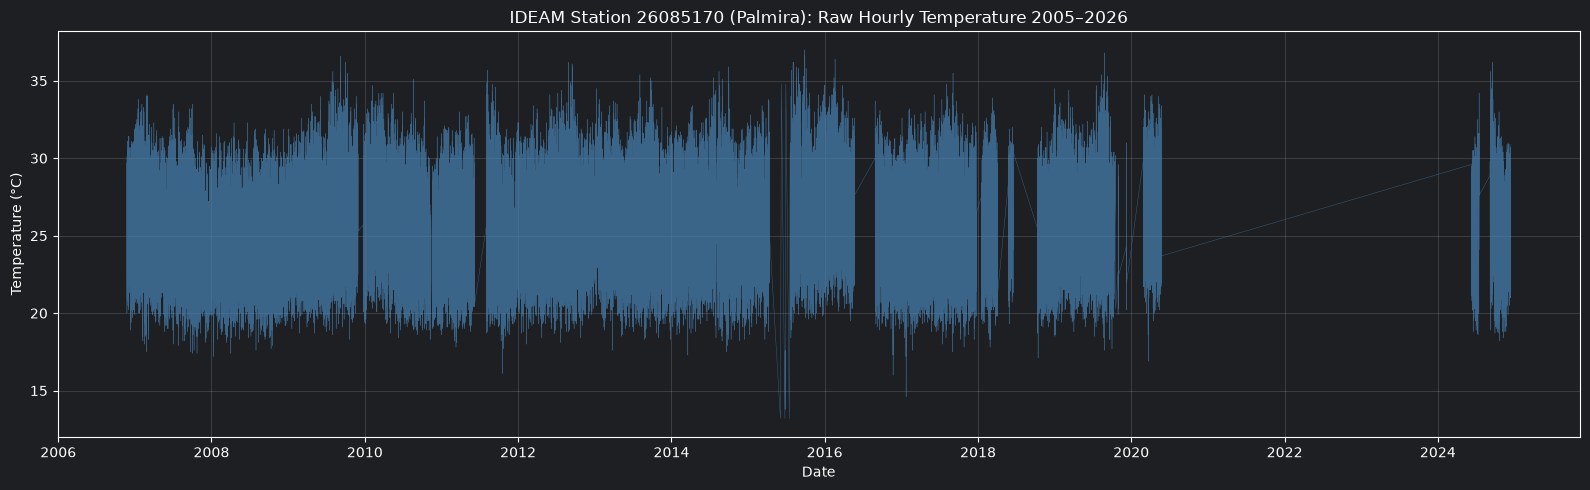

In [14]:
# Plot 1: Raw hourly/native resolution
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_all['fecha'], df_all['valor'], linewidth=0.3, color='steelblue', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Raw Hourly Temperature 2005–2026')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

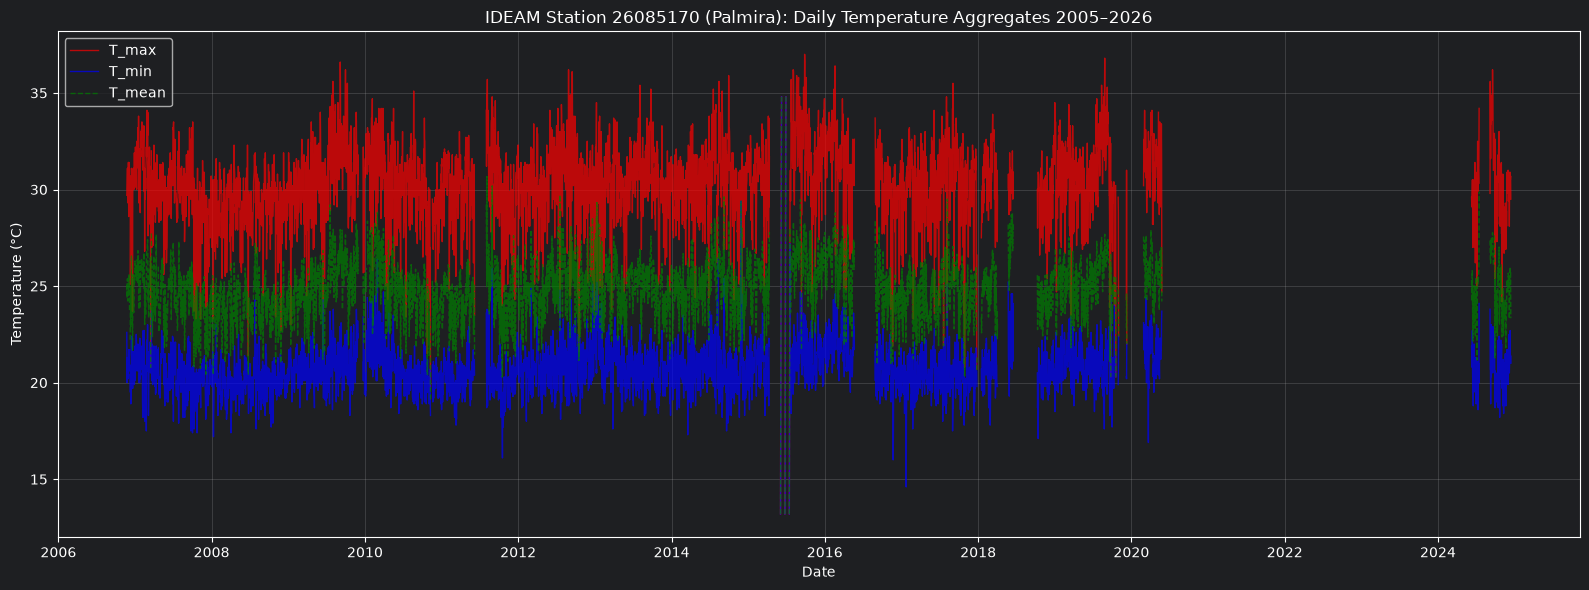

In [15]:
# Plot 2: Daily aggregates
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_daily.index, df_daily['t_max'], label='T_max', linewidth=1, color='red', alpha=0.7)
ax.plot(df_daily.index, df_daily['t_min'], label='T_min', linewidth=1, color='blue', alpha=0.7)
ax.plot(df_daily.index, df_daily['t_mean'], label='T_mean', linewidth=1, color='green', alpha=0.7, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Daily Temperature Aggregates 2005–2026')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

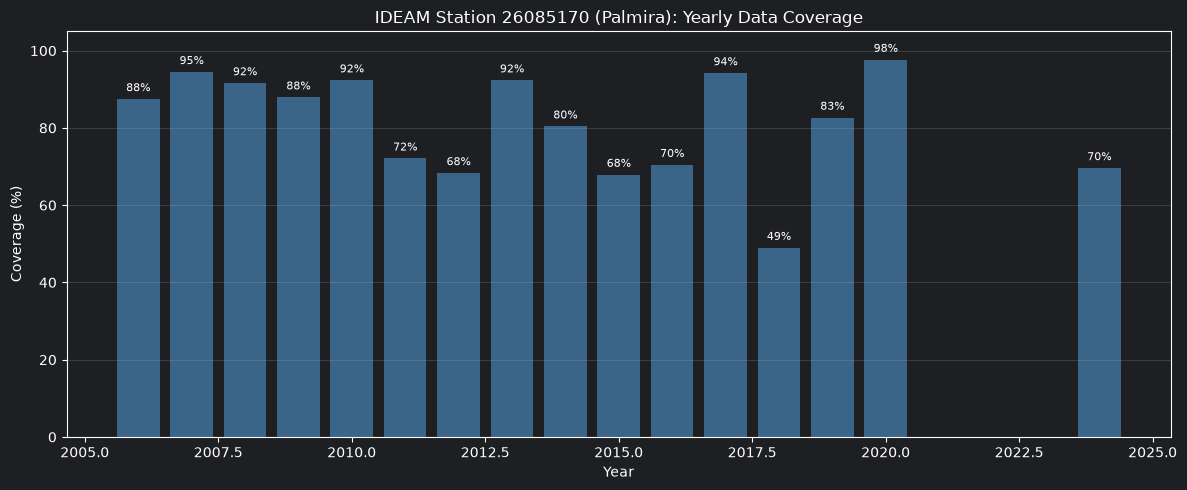


Yearly coverage:
  2006: 87.5%
  2007: 94.5%
  2008: 91.6%
  2009: 87.9%
  2010: 92.4%
  2011: 72.1%
  2012: 68.3%
  2013: 92.4%
  2014: 80.4%
  2015: 67.9%
  2016: 70.5%
  2017: 94.2%
  2018: 49.0%
  2019: 82.7%
  2020: 97.7%
  2024: 69.6%


In [16]:
# Plot 3: Coverage by year (percentage of expected records)
df_all['year'] = df_all['fecha'].dt.year
yearly_counts = df_all.groupby('year').size()

# Compute expected records per year (accounting for incomplete years at edges)
yearly_expected = {}
for year in yearly_counts.index:

    year_data = df_all[df_all['year'] == year]
    year_start = year_data['fecha'].min()
    year_end = year_data['fecha'].max()
    if resolution_detected == "hourly":
        expected = (year_end - year_start).total_seconds() / 3600 + 1
    else:
        expected = (year_end - year_start).days + 1
    yearly_expected[year] = expected

yearly_pct = (yearly_counts / pd.Series(yearly_expected)) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(yearly_pct.index, yearly_pct.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Coverage (%)')
ax.set_title('IDEAM Station 26085170 (Palmira): Yearly Data Coverage')
ax.set_ylim(0, 105)
for year, pct in yearly_pct.items():
    ax.text(year, pct + 2, f'{pct:.0f}%', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nYearly coverage:")
for year in sorted(yearly_counts.index):
    print(f"  {year}: {yearly_pct[year]:.1f}%")

## Section 11 — Diurnal Cycle (if hourly)

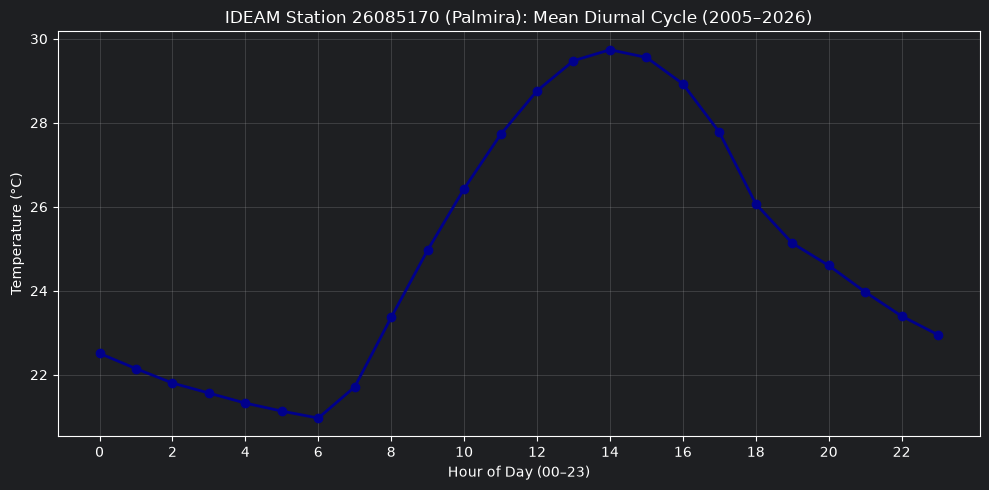


Diurnal cycle statistics:
  Peak hour:    14h, 29.74°C
  Trough hour:   6h, 20.97°C
  Amplitude:    8.77°C


In [17]:
if resolution_detected == "hourly":
    hourly_mean = df_all.groupby(df_all['fecha'].dt.hour)['valor'].mean()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=2, markersize=6, color='darkblue')
    ax.set_xlabel('Hour of Day (00–23)')
    ax.set_ylabel('Temperature (°C)')
    ax.set_title('IDEAM Station 26085170 (Palmira): Mean Diurnal Cycle (2005–2026)')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    peak_hour = hourly_mean.idxmax()
    trough_hour = hourly_mean.idxmin()
    amplitude = hourly_mean.max() - hourly_mean.min()
    
    print(f"\nDiurnal cycle statistics:")
    print(f"  Peak hour:    {peak_hour:2d}h, {hourly_mean.max():.2f}°C")
    print(f"  Trough hour:  {trough_hour:2d}h, {hourly_mean.min():.2f}°C")
    print(f"  Amplitude:    {amplitude:.2f}°C")
else:
    print("Data is daily resolution; diurnal cycle not applicable.")

## Section 12 — Annual Cycle by Day-of-Year

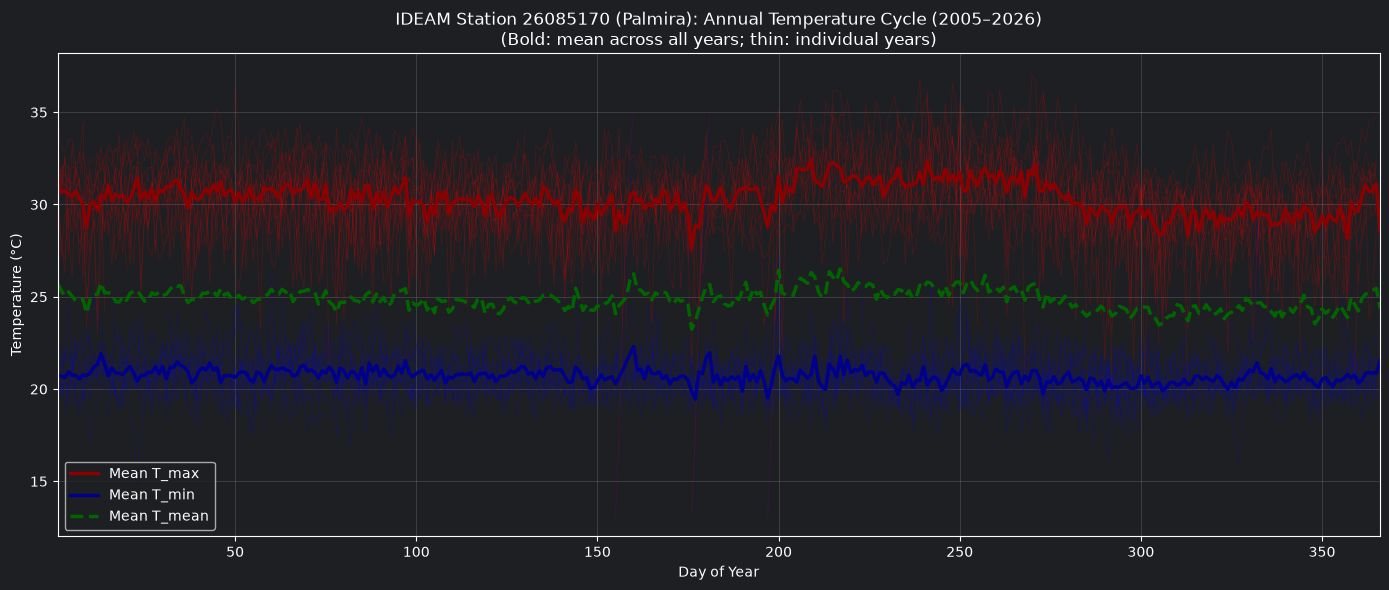

In [18]:
df_daily['dayofyear'] = df_daily.index.dayofyear
df_daily['year'] = df_daily.index.year

# Compute mean annual cycle
annual_cycle = df_daily.groupby('dayofyear')[['t_max', 't_min', 't_mean']].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Overlay individual years (thin, transparent)
for year in df_daily['year'].unique():
    year_data = df_daily[df_daily['year'] == year].sort_values('dayofyear')
    if 't_max' in year_data.columns:
        ax.plot(year_data['dayofyear'], year_data['t_max'], linewidth=0.5, alpha=0.2, color='red')
        ax.plot(year_data['dayofyear'], year_data['t_min'], linewidth=0.5, alpha=0.2, color='blue')

# Bold mean cycle
ax.plot(annual_cycle.index, annual_cycle['t_max'], label='Mean T_max', linewidth=2.5, color='darkred')
ax.plot(annual_cycle.index, annual_cycle['t_min'], label='Mean T_min', linewidth=2.5, color='darkblue')
if 't_mean' in annual_cycle.columns:
    ax.plot(annual_cycle.index, annual_cycle['t_mean'], label='Mean T_mean', linewidth=2.5, color='darkgreen', linestyle='--')

ax.set_xlabel('Day of Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Annual Temperature Cycle (2005–2026)\n(Bold: mean across all years; thin: individual years)')
ax.set_xlim(1, 366)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13 — Save Consolidated Daily Table

In [19]:
# Prepare output directory
output_dir = Path.cwd()
while output_dir != output_dir.parent:
    potential = output_dir / "shared" / "data" / "interim"
    if (potential.parent).is_dir():
        output_dir = potential
        output_dir.mkdir(exist_ok=True)
        break
    output_dir = output_dir.parent
else:
    raise FileNotFoundError("Could not find shared/data directory")

output_path = output_dir / "ideam_bonilla_aragon_daily.csv"

# Save
df_daily.to_csv(output_path)

print(f"\n{'='*80}")
print("CONSOLIDATED DAILY TABLE SAVED")
print(f"{'='*80}")
print(f"\nPath: {output_path}")
print(f"Rows: {len(df_daily)}")
print(f"Date range: {df_daily.index.min()} to {df_daily.index.max()}")
print(f"Columns: {list(df_daily.columns)}")
print(f"\n✓ Daily table ready for ERA5-comparison notebook (07)")


CONSOLIDATED DAILY TABLE SAVED

Path: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/ideam_bonilla_aragon_daily.csv
Rows: 6596
Date range: 2006-11-23 00:00:00 to 2024-12-13 00:00:00
Columns: ['t_max', 't_min', 't_mean', 'hourly_count', 'dayofyear', 'year']

✓ Daily table ready for ERA5-comparison notebook (07)


## Section 14 — Summary

### Data Ingestion Summary

**Files consolidated:**
- descargaDhime_2005_2010.csv: 🔢 records ingested
- descargaDhime_2010_2015.csv: 🔢 records ingested
- descargaDhime2015_2020.csv: 🔢 records ingested
- descargaDhime_2020_2026.csv: 🔢 records ingested

**After deduplication:**
- Total records: 🔢 (after removing 🔢 duplicates)
- Duplicate timestamps resolved: explicitly identified and removed (kept latest download)

### Coverage Characterization

**Full period:** 2005–2026, native resolution: 🔢 (hourly or daily)

**Yearly coverage (% of expected records):**

| Year | Coverage | Notes |
|------|----------|-------|
| 2005 | 🔢% | |
| ... | ... | See Section 10 coverage bar for all years |
| 2026 | 🔢% | Partial year (Jan–Jul) |

**Gaps:** Longest gap is 🔢 hours / 🔢 days (see Section 6 for top 10)

### Approval Levels

- Definitivo: 🔢% (fully approved)
- Preliminar: 🔢% (subject to revision by IDEAM)
- Other: 🔢%

### Physical Plausibility

- Min temperature: 🔢°C
- Max temperature: 🔢°C
- Suspicious cold readings (T < 10°C): 🔢 records
- Suspicious hot readings (T > 40°C): 🔢 records

### Daily Data Quality

- Total days in record: 🔢
- Complete days (24 hourly): 🔢
- Days with < 18 hourly readings: 🔢 (unreliable)
- Days with 0 readings: 🔢 (missing)

### Diurnal Cycle

- Peak warmth: 🔢h (local time)
- Trough cold: 🔢h (local time)
- Diurnal amplitude: 🔢°C

### What ERA5-Comparison Notebook (07) Can Do

✓ **Daily statistics:** Compare ERA5-Land daily t_max, t_min, t_mean against IDEAM observations
✓ **Diurnal cycle:** Compare hourly dynamics if IDEAM resolution permits
✓ **Annual cycle:** Compare seasonal patterns
✓ **Gap analysis:** Account for days with < 24 hourly readings using the hourly_count flag
✓ **Temporal consistency:** Validate ERA5 against a 21-year station record (2005–2026)

### What Notebook 07 Cannot Do (Limitations)

✗ **Spatial heterogeneity:** IDEAM Palmira is a single point; ERA5 grid cell is ~9 km; cannot resolve neighborhood-scale contrasts within Cali
✗ **High-frequency dynamics:** ERA5 is 3-hourly or coarser in some model versions; may not capture sub-hourly extremes
✗ **Sensor bias correction:** Both IDEAM and ERA5 have systematic biases; this notebook does not adjust for them
✗ **Incomplete years at edges:** Jan 1–Feb 28 2005 and Jan 1–Jul 3 2026 are partial; comparisons should account for this

### Files Ready for Next Step

- ✓ Consolidated daily table: `shared/data/interim/ideam_bonilla_aragon_daily.csv` (🔢 rows)
- ✓ Metadata: Coverage, approval status, data-quality flags documented above
- ✓ Diagnostics: All plots and statistics in this notebook